<a href="https://colab.research.google.com/github/RonGarcia-hub/CPE018-CPE31S2/blob/main/Garcia_Activity_5_Line_and_Circle_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Technological Institute of the Philippines | Quezon City - Computer Engineering
--- | ---
Course Code: | CPE 018
Code Title: | Emerging Technologies in CpE 1 - Fundamentals of Computer Vision
2st Semester | AY 2025 - 2026
<hr> | <hr>
<u>**ACTIVITY NO.5** | **Line and Circle Detection**
**Name** | Garcia, Ron Allen
**Section** | CPE31S2
**Date Performed**: | 1/20/2026
**Date Submitted**: | 1/20/2026
**Instructor**: | Engr. Maria Rizette Sayo

<hr>

## 1. Objectives

This activity aims to introduce students to openCV's APIs for Hough Transform.

## 2. Intended Learning Outcomes (ILOs)
After this activity, the students should be able to:
* Utilize openCV for circle and line detection.
* Analyze the use of hough Line and Circle function for finding objects in an image.

## 3. Procedures and Outputs

Detecting edges and contours are not only common and important tasks, they also constitute the basis for other complex operations. Lines and shape detection go hand in hand with edge and contour detection, so let's examine how OpenCV implements these.

### Line Detection

The theory behind lines and shape detection has its foundation in a technique called the Hough transform, invented by Richard Duda and Peter Hart, who extended (generalized) the work done by Paul Hough in the early 1960s.

Let's take a look at OpenCV's API for the Hough transforms.

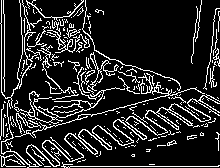

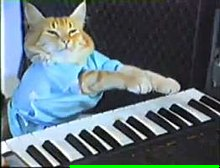

In [ ]:
# Image source: https://en.wikipedia.org/wiki/Keyboard_Cat

from google.colab.patches import cv2_imshow
import cv2
import numpy as np

img = cv2.imread('/content/Keyboard_cat.jpg')
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray,50,120)
minLineLength = 20
maxLineGap = 5
lines = cv2.HoughLinesP(edges,1,np.pi/180,100,minLineLength,
        maxLineGap)
for x1,y1,x2,y2 in lines[0]:
  cv2.line(img,(x1,y1),(x2,y2),(0,255,0),2)

cv2_imshow(edges)
cv2_imshow(img)

The crucial point of this simple script —aside from the HoughLines function call— is the setting of minimum line length (shorter lines will be discarded) and the maximum line gap, which is the maximum size of a gap in a line before the two segments start being considered as separate lines.

Also note that the HoughLines function takes a single channel binary image, processed through the Canny edge detection filter. Canny is not a strict requirement, however; an image that's been denoised and only represents edges, is the ideal source for a Hough transform, so you will find this to be a common practice.

The parameters of HoughLinesP are as follows:
- The image we want to process.
- The geometrical representations of the lines, rho and theta, which are usually 1 and np.pi/180.
- The threshold, which represents the threshold below which a line is discarded. The Hough transform works with a system of bins and votes, with each bin representing a line, so any line with a minimum of the <threshold> votes is retained, the rest discarded.
- MinLineLength and MaxLineGap, which we mentioned previously

**Questions:**

1. Which line of code is responsible for setting the minimum line length?
2. What is the mathematical formula for Hough transform and explain how it finds lines.

### Circle Detection

OpenCV also has a function for detecting circles, called HoughCircles. It works in a very similar fashion to HoughLines, but where minLineLength and maxLineGap were the parameters to discard or retain lines, HoughCircles has a minimum distance between circles' centers, minimum, and maximum radius of the circles. Here's the obligatory example:

Before going into the sample code, check first: **What is the HoughCircles function and what are its parameters?**

In [4]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Our testing value
n = 5

planets = cv2.imread('/content/planets.jpg')
gray_img = cv2.cvtColor(planets, cv2.COLOR_BGR2GRAY)
img = cv2.medianBlur(gray_img, n) # We will change this value passed as parameter and observe results
cimg = cv2.cvtColor(img,cv2.COLOR_GRAY2BGR)
circles = cv2.HoughCircles(img,cv2.HOUGH_GRADIENT,1,120,
                            param1=100,param2=30,minRadius=0,
                                maxRadius=0)
circles = np.uint16(np.around(circles))

for i in circles[0,:]:
  # draw the outer circle
  cv2.circle(planets,(i[0],i[1]),i[2],(0,255,0),2)
  # draw the center of the circle
  cv2.circle(planets,(i[0],i[1]),2,(0,0,255),3)

cv2.imwrite("planets_circles.jpg", planets)
cv2_imshow(planets)

error: OpenCV(4.12.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


What happens to the code once you run **and the value of n is 5**?

Change the value to 9, **what happens to the image**?

Lastly, change the value to 15, **what can you say about the resulting image?**

Provide an analysis of the output so far. How does the code help the changes in the resulting image?

## 4. Supplementary Activity

The attached image contains coins used in the Philippines.

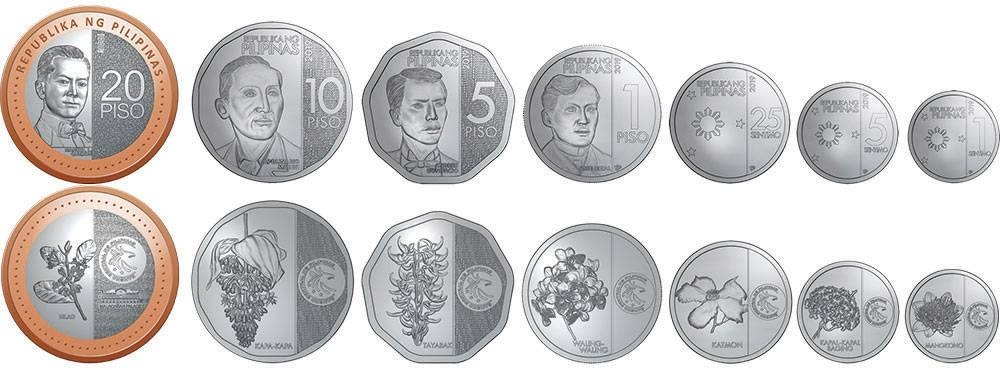

Your job is to count the amount of coins (denomation not included, no sum of prices; just the amount of coins present) through either line detection or circle detection.

- Create a function using line detection and pass this image as parameter, what is the output? Can you use houghlines to count circles?
- Create a function using circle detection and pass this image as parameter, show the output? Can you use houghcircles to count the circles?

Saving Coins.jpg to Coins (5).jpg
Using image: Coins (5).jpg
Number of lines detected: 765
Line Detection Output:


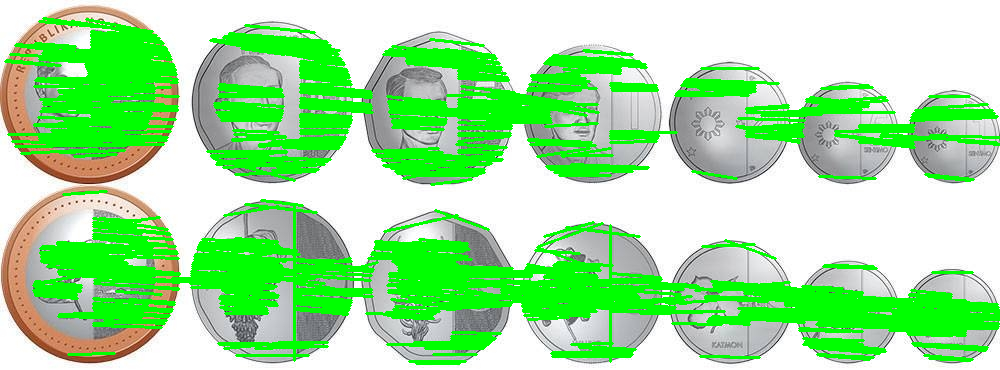

In [11]:
# Create a function using line detection and pass this image as parameter, what is the output? Can you use houghlines to count circles?

# Step 1: Upload image from local computer
from google.colab import files
uploaded = files.upload()

# Step 2: Imports
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Step 3: Automatically get uploaded filename
image_name = list(uploaded.keys())[0]
image_path = f"/content/{image_name}"

print("Using image:", image_name)

# Step 4: Line detection function using HoughLinesP
def detect_lines(image_path):
    img = cv2.imread(image_path)

    if img is None:
        raise FileNotFoundError("Image could not be loaded.")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150)

    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi / 180,
        threshold=100,
        minLineLength=40,
        maxLineGap=10
    )

    line_count = 0
    if lines is not None:
        line_count = len(lines)
        for x1, y1, x2, y2 in lines[:, 0]:
            cv2.line(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    return line_count, img, edges

# Step 5: Run detection and show output
line_count, output, edges = detect_lines(image_path)

print("Number of lines detected:", line_count)

print("Line Detection Output:")
cv2_imshow(output)

#The output shows you cannot count circles with lines,
#I have observed that rather than the coins it counts the bundled up words or lines that are in the coins which makes it so that houghlines is not usable for circle detection.


Saving Coins.jpg to Coins (6).jpg
Using image: Coins (6).jpg
Number of coins detected: 15


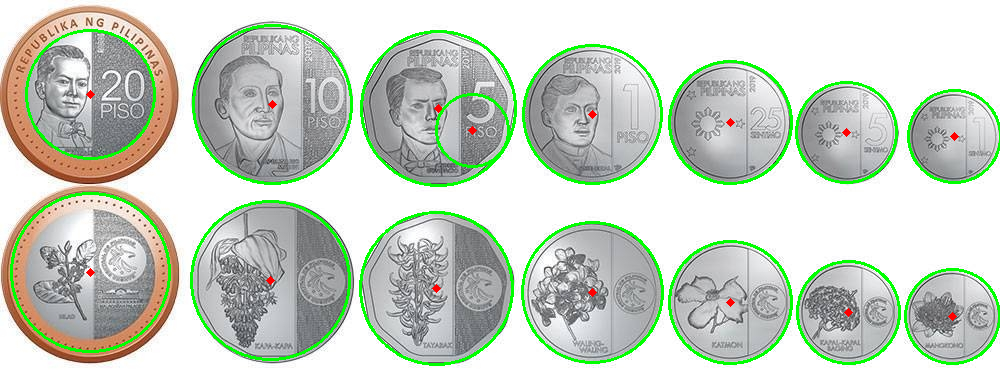

In [12]:
#Create a function using circle detection and pass this image as parameter, what is the output? Can you use hough circle to count circles?

from google.colab import files
uploaded = files.upload()

import cv2
import numpy as np
import os
from google.colab.patches import cv2_imshow

image_name = list(uploaded.keys())[0]
image_path = f"/content/{image_name}"

print("Using image:", image_name)

def count_coins_using_circles(image_path):
    img = cv2.imread(image_path)

    if img is None:
        raise FileNotFoundError("Image could not be loaded.")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.medianBlur(gray, 9)

    circles = cv2.HoughCircles(
        blurred,
        cv2.HOUGH_GRADIENT,
        dp=1,
        minDist=40,
        param1=100,
        param2=30,
        minRadius=20,
        maxRadius=80
    )

    count = 0
    if circles is not None:
        circles = np.uint16(np.around(circles))
        count = circles.shape[1]

        for x, y, r in circles[0]:
            cv2.circle(img, (x, y), r, (0, 255, 0), 2)
            cv2.circle(img, (x, y), 2, (0, 0, 255), 3)

    return count, img

count, output = count_coins_using_circles(image_path)

print("Number of coins detected:", count)
cv2_imshow(output)

#The output shows that I have 14 coins with the circle detection being bale to output the circle with green outline
#It also shows a red dot to mark the center of the circle that it has detected.


## 5. Summary, Conclusions and Lessons Learned

# Summary

The activity demonstrated how OpenCV's Hough Transform function operates to identify lines and circles within digital image files. The HoughLinesP method for line detection identified straight edges but failed to count circular objects, including coins. The HoughCircles method for circle detection worked better because it detected coins accurately through their circular form. This allowed for correct coin counting.


## Conclusion

The outcome indicates that proper selection of the detection technique is essential in performing computer vision operations. Line detection using the Hough transform is suitable for images dominated by straight line features, whereas circular detection using the Hough transform is most appropriate for circular objects such as coins. The task re-emphasizes the significance of geometrical insight for proper image analysis output.

<hr/>

***Proprietary Clause***

*Property of the Technological Institute of the Philippines (T.I.P.). No part of the materials made and uploaded in this learning management system by T.I.P. may be copied, photographed, printed, reproduced, shared, transmitted, translated, or reduced to any electronic medium or machine-readable form, in whole or in part, without the prior consent of T.I.P.*